In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)
train_path = path + "/asl_alphabet_train/asl_alphabet_train"
test_path = path + "/asl_alphabet_test/asl_alphabet_test"
print("Path to train files:", train_path)
print("Path to test files:", test_path)

Path to dataset files: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1
Path to train files: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train
Path to test files: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_test/asl_alphabet_test


In [ ]:
clases = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "U",
    "V",
    "W",
    "X",
    "Y",
]

len(clases)

24

In [ ]:
import os
ruta = train_path
carpetas = os.listdir(ruta)
carpetas.sort()
for carpeta in carpetas:
  print(carpeta)

A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z
del
nothing
space


In [19]:
import os
def length_of_folders(path, clases):
  lista  = []
  for clase in clases:
    ruta = path + '/' + clase
    imagenes = os.listdir(ruta)
    tupla = (len(imagenes),clase)
    lista.append(tupla)
    #print(f"{len(imagenes)}: {clase}")
  lista.sort()
  for tupla in lista:
    print(f"{tupla[0]}: {tupla[1]}")
  return min(lista)[0]
# print(length)
train_len = length_of_folders(train_path, clases)
print(train_len)
#test_len = length_of_folders(test_path, clases)
#print(test_len)

3000: A
3000: B
3000: C
3000: D
3000: E
3000: F
3000: G
3000: H
3000: I
3000: K
3000: L
3000: M
3000: N
3000: O
3000: P
3000: Q
3000: R
3000: S
3000: T
3000: U
3000: V
3000: W
3000: X
3000: Y
3000


In [21]:
import shutil
import os
import cv2
import numpy as np

def crear_data_grayscale(carpeta_fuente, carpeta_destino, num):
  imagenes = os.listdir(carpeta_fuente)
  for i, nombreimg in enumerate(imagenes):
    if i < num:
      ruta = carpeta_fuente + '/' + nombreimg
      image = cv2.imread(ruta)
      if image is None:
          print("Error: No se pudo cargar la imagen.")
          continue
      gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

      if not os.path.exists(carpeta_destino):
          os.makedirs(carpeta_destino)
      cv2.imwrite(carpeta_destino + '/' + nombreimg, gray_image)
  imagenes_salidas = os.listdir(carpeta_destino)
  print(len(imagenes_salidas))

In [22]:
import shutil
import os

def crear_data(carpeta_fuente, carpeta_destino, num):
  imagenes = os.listdir(carpeta_fuente)
  if not os.path.exists(carpeta_destino):
          os.makedirs(carpeta_destino)
  for i, nombreimg in enumerate(imagenes):
    if i < num:
      #Copia de la carpeta fuente a la destino
      shutil.copy(carpeta_fuente + '/' + nombreimg, carpeta_destino + '/' + nombreimg)
  imagenes_salidas = os.listdir(carpeta_destino)
  print(len(imagenes_salidas))


In [23]:
def usar_funcion_de_carpetas(carpeta_fuente, carpeta_destino, clases, funcion, num):
  for clase in clases:
    fuente = carpeta_fuente + '/' + clase
    destino = carpeta_destino + '/' + clase
    funcion(fuente, destino, num)

In [24]:
fuente = train_path
destino = "/content/train"
usar_funcion_de_carpetas(fuente, destino, clases, crear_data_grayscale, train_len)
fuente = test_path
#destino = "/content/test"
#usar_funcion_de_carpetas(fuente, destino, clases, crear_data_grayscale, test_len)

3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000
3000


In [31]:
color = "grayscale"

In [42]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# 1. Configurar rutas y parámetros
dataset_path = "/content/train"
target_size = (64, 64)  # Redimensionar a 256x256
batch_size = 32
epochs = 20
saved_models = "/content/saved_models"

# 2. Preprocesamiento y aumento de datos
datagen = ImageDataGenerator(
    rescale = 1.0/255.0,  # Normalización de píxeles
    rotation_range = 20,  # Rotación aleatoria
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip = True,
    validation_split=0.3
)

# 3. Cargar las imágenes de las 4 clases
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size = target_size,
    batch_size = batch_size,
    color_mode = color,
    class_mode = 'categorical',  # Clasificación multiclase
    classes = clases,
    subset='training'  # Conjunto de entrenamiento
)

valid_gen = datagen.flow_from_directory(
    dataset_path,
    target_size = target_size,
    batch_size = batch_size,
    color_mode = color,
    class_mode = 'categorical',  # Clasificación multiclase
    classes = clases,
    subset='validation'
)

# 4. Construir el modelo
Model = Sequential([
    Conv2D(64, kernel_size= (3,3),padding='same', activation='relu', input_shape=(target_size[0], target_size[1],1)),
    Conv2D(64, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),


    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(256, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(24, activation='softmax')
    ])

# 5. Compilar el modelo
Model.compile(optimizer = "adam",
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )

# 6. Resumen del modelo
Model.summary()
if not os.path.exists(saved_models):
  os.makedirs(saved_models)
filepath= "/content/saved_models/weights-improvement-{epoch:02d}-{val_accuracy:.2f}.keras" #File name includes epoch and validation accuracy.
#Use Mode = max for accuracy and min for loss.
checkpoint = ModelCheckpoint(filepath, monitor ='val_accuracy', verbose = 1, save_best_only = True, mode = 'max')
# 7. Callback para EarlyStopping
early_stop = EarlyStopping(
    monitor ='val_loss',  # Monitorear la pérdida en el conjunto de validación
    patience = 5,  # Número de épocas sin mejora antes de detener el entrenamiento
    restore_best_weights=True  # Restaurar los mejores pesos encontrados
)

callbacks_list = [checkpoint, early_stop]

# 8. Entrenar el modelo con EarlyStopping
history = Model.fit(
    train_gen,
    epochs = epochs,
    validation_data=valid_gen,
    callbacks=callbacks_list,
    verbose=1
    )

# 9. Evaluar el modelo
loss, accuracy = Model.evaluate(valid_gen)
print(f"Pérdida en validación: {loss}")
print(f"Precisión en validación: {accuracy}")

# 10. Guardar el modelo
Model.save("senas_modelo.keras")

Found 50400 images belonging to 24 classes.
Found 21600 images belonging to 24 classes.


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_84 (Conv2D)                   │ (None, 64, 64, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_85 (Conv2D)                   │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_42               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_41 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_86 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_87 (Conv2D)                   │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_43               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_42 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_88 (Conv2D)                   │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_89 (Conv2D)                   │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_44               │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_43 (MaxPooling2D)      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_90 (Conv2D)                   │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_91 (Conv2D)                   │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_45               │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_44 (MaxPooling2D)      │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_92 (Conv2D)                   │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_93 (Conv2D)                   │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_46               │ (None, 4, 4, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │              

 Total params: 9,854,744 (37.59 MB)

 Trainable params: 9,851,544 (37.58 MB)

 Non-trainable params: 3,200 (12.50 KB)

Epoch 1/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0456 - loss: 3.1951
Epoch 1: val_accuracy improved from -inf to 0.04162, saving model to /content/saved_models/weights-improvement-01-0.04.keras
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 120s 67ms/step - accuracy: 0.0456 - loss: 3.1951 - val_accuracy: 0.0416 - val_loss: 3.1785
Epoch 2/20
1574/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0664 - loss: 3.0206
Epoch 2: val_accuracy improved from 0.04162 to 0.11444, saving model to /content/saved_models/weights-improvement-02-0.11.keras
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.0664 - loss: 3.0205 - val_accuracy: 0.1144 - val_loss: 3.0117
Epoch 3/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1154 - loss: 2.8389
Epoch 3: val_accuracy did not improve from 0.11444
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 143s 64ms/step - accuracy: 0.1154 - loss: 2.8388 - val_accuracy: 0.0824 - val_loss: 4.5897
Epoch 4/20
1574/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accura

Found 21600 images belonging to 24 classes.


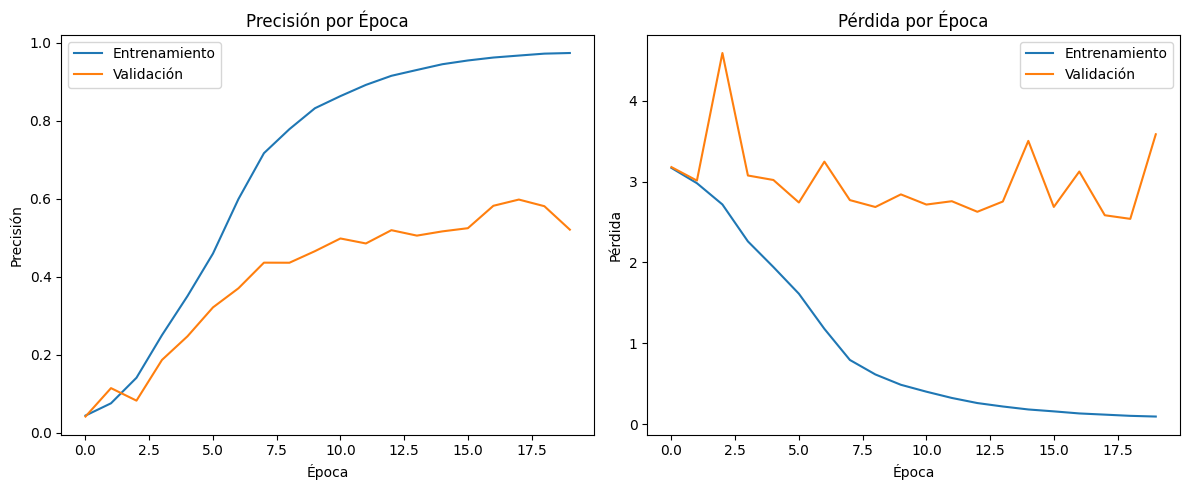

675/675 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step


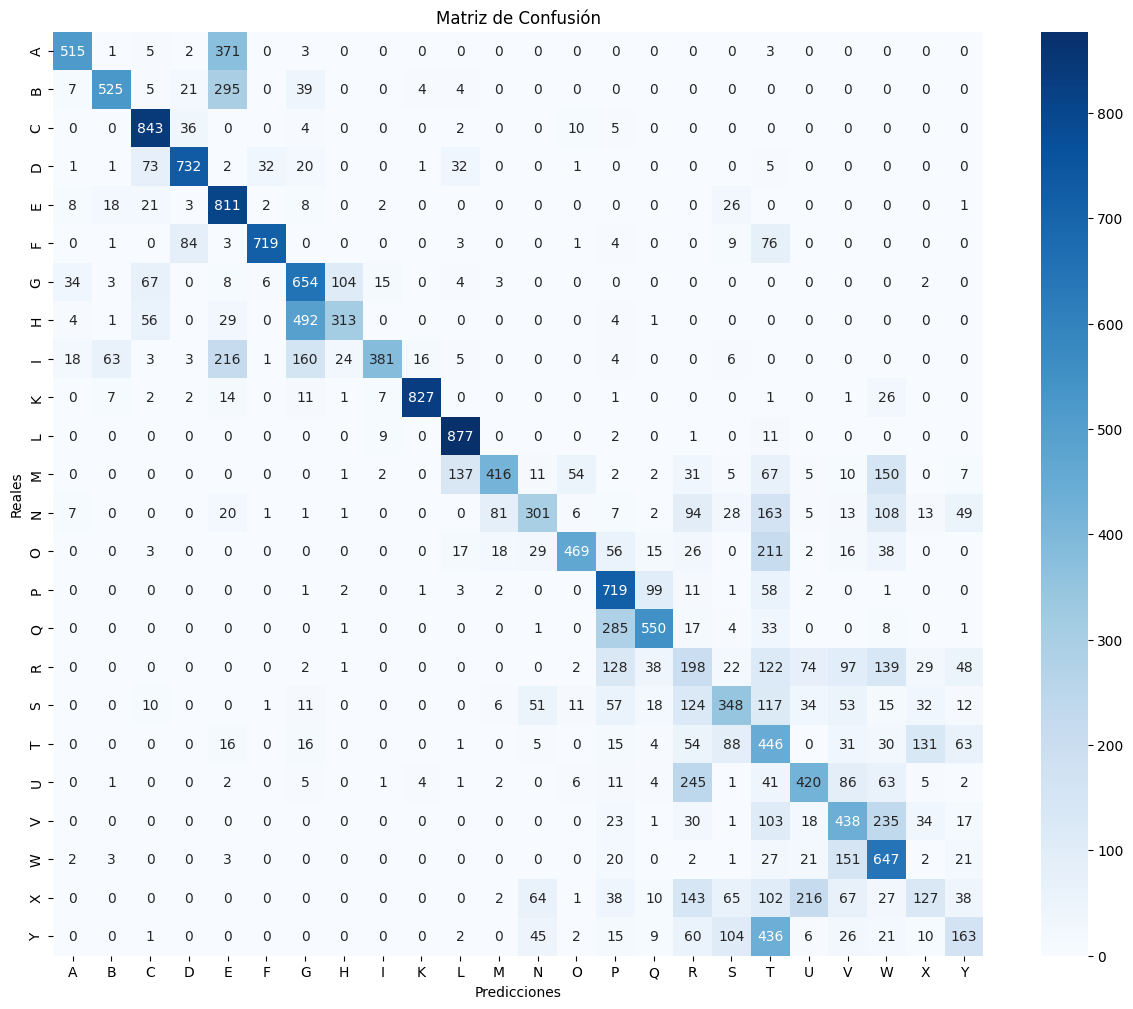

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


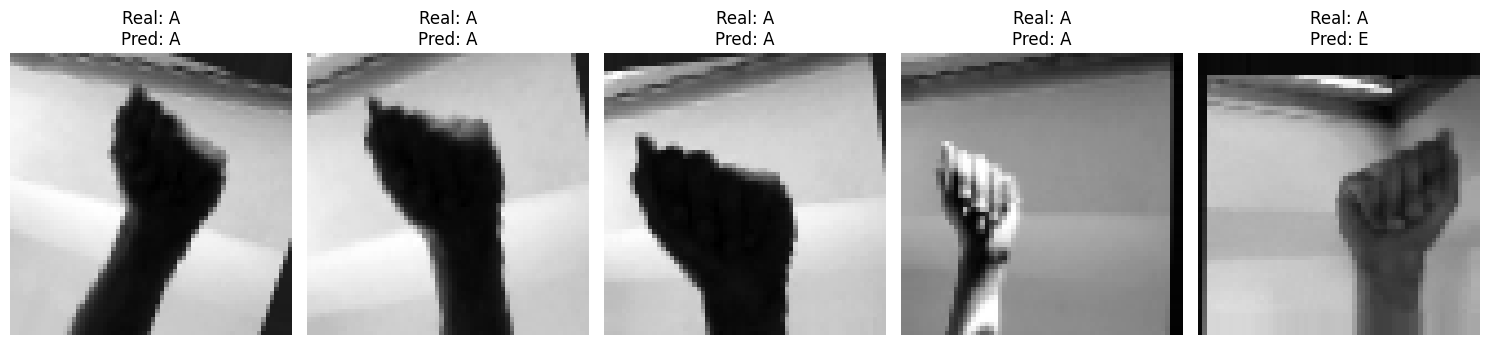

In [61]:
# ==============================================
# LIBRERÍAS NECESARIAS (AGREGAR AL INICIO)
# ==============================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import plot_model

# ==============================================
# MODIFICACIONES PREVIAS AL ENTRENAMIENTO
# ==============================================

# A. Asegurar que el validation_gen no mezcle los datos (agregar shuffle=False)
valid_gen = datagen.flow_from_directory(
    dataset_path,
    target_size = target_size,
    batch_size = batch_size,
    color_mode = color,
    class_mode = 'categorical',
    classes = clases,
    subset='validation',
    shuffle=False  # ¡IMPORTANTE PARA LA MATRIZ DE CONFUSIÓN!
)

# ==============================================
# CÓDIGO PARA GRÁFICAS (AGREGAR DESPUÉS DEL ENTRENAMIENTO)
# ==============================================

# 1. Curvas de Entrenamiento (Accuracy/Loss)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión por Época')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida por Época')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# 2. Matriz de Confusión (¡Requiere que valid_gen tenga shuffle=False!)
valid_gen.reset()  # Reiniciar el generador
y_pred = Model.predict(valid_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Obtener las etiquetas reales desde el generador
y_true_classes = valid_gen.labels

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=clases, yticklabels=clases)  # Usar tu lista de clases
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Reales')
plt.savefig('confusion_matrix.png')
plt.show()

# 3. Ejemplos de Predicciones
valid_gen.reset()
x_batch, y_batch = next(valid_gen)  # Obtener un batch de datos
pred_batch = Model.predict(x_batch)
pred_labels = np.argmax(pred_batch, axis=1)
true_labels = np.argmax(y_batch, axis=1)

plt.figure(figsize=(15, 7))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_batch[i].squeeze(), cmap='gray')  # Eliminar canal si es escala de grises
    plt.title(f'Real: {clases[true_labels[i]]}\nPred: {clases[pred_labels[i]]}')
    plt.axis('off')

plt.tight_layout()
plt.savefig('predictions_examples.png')
plt.show()

# 4. Arquitectura del Modelo
try:
    plot_model(Model, to_file='model_architecture.png', show_shapes=True)  # ¡Model con mayúscula!
except ImportError:
    print("Instala pydot y graphviz: pip install pydot graphviz")

# ==============================================
# OBSERVACIONES FINALES
# ==============================================
# - Asegúrate de tener instaladas las librerías: seaborn, matplotlib.
# - Las etiquetas de clase (clases) deben coincidir con las usadas en tu generador.
# - Si tienes más de 15 clases, usa annot=False en la matriz de confusión.

Cargando datos de validación: 100%|██████████| 675/675 [00:22<00:00, 30.55it/s]


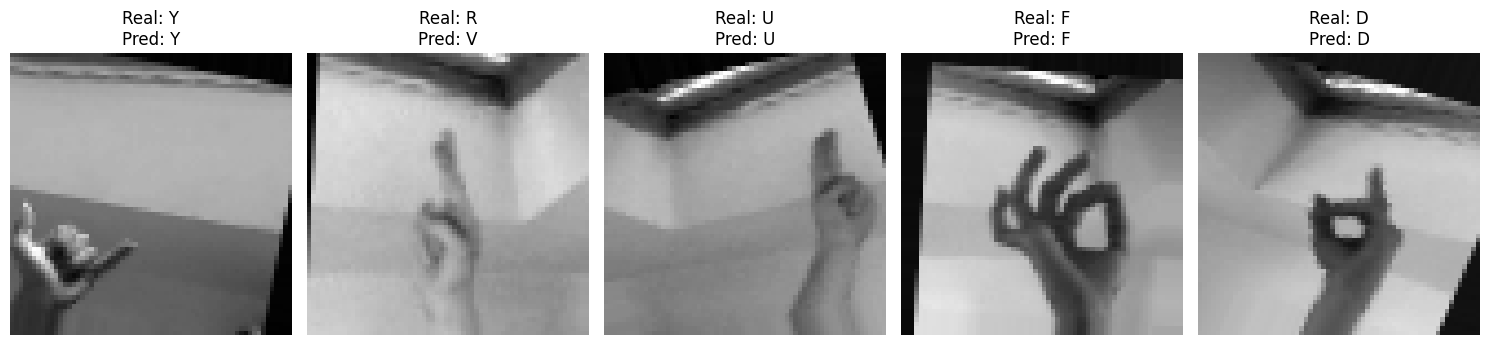

In [68]:
# 3. Ejemplos de Predicciones (MUESTRA VARIAS CLASES)
valid_gen.reset()  # Reiniciar el generador

# Obtener TODAS las imágenes y etiquetas del conjunto de validación
num_samples = valid_gen.samples  # Número total de muestras en validación
all_images = []
all_true_labels = []

# Iterar sobre todo el generador de validación
for _ in tqdm(range(len(valid_gen)), desc="Cargando datos de validación"):
    x_batch, y_batch = next(valid_gen)
    all_images.append(x_batch)
    all_true_labels.append(y_batch)

# Concatenar todos los batches
all_images = np.concatenate(all_images, axis=0)
all_true_labels = np.concatenate(all_true_labels, axis=0)

# Obtener 5 índices aleatorios de diferentes clases
unique_classes = np.unique(np.argmax(all_true_labels, axis=1))
selected_indices = []
for cls in np.random.choice(unique_classes, size=5, replace=False):  # 5 clases únicas
    indices = np.where(np.argmax(all_true_labels, axis=1) == cls)[0]
    selected_indices.append(np.random.choice(indices))

# Generar predicciones para los índices seleccionados
selected_images = all_images[selected_indices]
selected_true = np.argmax(all_true_labels[selected_indices], axis=1)
selected_pred = np.argmax(Model.predict(selected_images, verbose=0), axis=1)

# Obtener nombres de las clases desde el generador
class_names = list(valid_gen.class_indices.keys())  # Esto debe ser ['A', 'B', ..., 'Z']

# Graficar
plt.figure(figsize=(15, 7))
for i, (idx, true_label, pred_label) in enumerate(zip(selected_indices, selected_true, selected_pred)):
    plt.subplot(1, 5, i+1)
    plt.imshow(all_images[idx].squeeze(), cmap='gray')
    plt.title(f'Real: {class_names[true_label]}\nPred: {class_names[pred_label]}')
    plt.axis('off')

plt.tight_layout()
plt.savefig('predictions_examples.png')
plt.show()

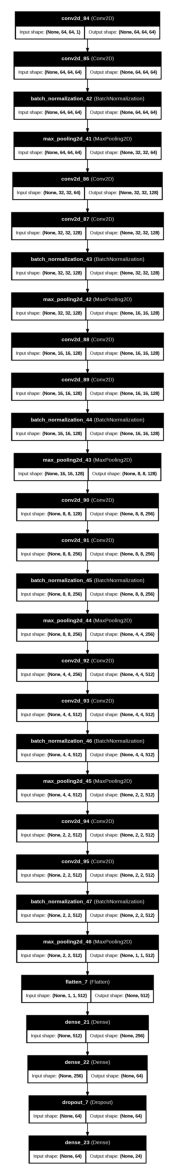

In [ ]:
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

try:
    # Generar y guardar el diagrama
    plot_model(
        Model,  # Tu modelo (¡con mayúscula!)
        to_file='arquitectura_red_neuronal.png',
        show_shapes=True,     # Muestra las formas de entrada/salida
        show_layer_names=True,  # Muestra nombres de capas
        dpi=96,               # Resolución de la imagen
        expand_nested=True    # Detalla capas dentro de bloques (ej. Secuenciales)
    )

    # Mostrar la imagen en el notebook o entorno local
    img = plt.imread('arquitectura_red_neuronal.png')
    plt.figure(figsize=(20, 15))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

except ImportError:
    print("Instala las dependencias: pip install pydot graphviz")

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import pyautogui
from PIL import Image

# 1. Cargar el modelo entrenado
model = tf.keras.models.load_model("new_model_hackaton_version.keras")  # Asegúrate de que el modelo esté en la ruta correcta

# 2. Definir el tamaño de la región de la pantalla a capturar
screen_width, screen_height = 260, 260  # Resolución de 400x400

# 3. Definir las etiquetas de las clases
class_names = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",
    "Grape___Esca_(Black_Measles)",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Grape___healthy",
    "Tomato___Late_blight",
    "Tomato___Septoria_leaf_spot",
    "Tomato___healthy"
]

# 4. Función para preprocesar la imagen
def preprocess_image(image):
    # Convertir a escala de grises
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Redimensionar a 256x256 (tamaño esperado por el modelo)
    resized_image = cv2.resize(gray_image, (128, 128))
    # Normalizar los valores de píxeles
    normalized_image = resized_image / 255.0
    # Expandir dimensiones para que coincida con la entrada del modelo (256, 256, 1)
    input_image = np.expand_dims(normalized_image, axis=-1)
    input_image = np.expand_dims(input_image, axis=0)  # Añadir dimensión del batch
    return input_image

# 5. Función para predecir la clase y la confianza
def predict_plant(image):
    # Preprocesar la imagen
    input_image = preprocess_image(image)
    # Realizar la predicción
    predictions = model.predict(input_image)
    # Obtener la clase predicha y su confianza
    predicted_class_index = np.argmax(predictions, axis=1)[0]  # Índice de la clase predicha
    predicted_class_name = class_names[predicted_class_index]  # Nombre de la clase predicha
    confidence = np.max(predictions)  # Confianza de la predicción (valor máximo del array de predicciones)
    return predicted_class_name, confidence

# 6. Capturar la pantalla en tiempo real y realizar predicciones
print("Iniciando detección en tiempo real...")
while True:
    # Capturar la pantalla
    screenshot = pyautogui.screenshot(region=(290, 370, screen_width, screen_height))
    screenshot = np.array(screenshot)  # Convertir a un array de NumPy
    screenshot = cv2.cvtColor(screenshot, cv2.COLOR_RGB2BGR)  # Convertir a BGR (OpenCV usa BGR por defecto)

    # Realizar la predicción
    predicted_class_name, confidence = predict_plant(screenshot)

    # Mostrar el resultado en la pantalla
    label = f"{predicted_class_name} ({confidence * 100:.2f}%)"  # Formato: "Clase (Confianza %)"

    # Mostrar el texto en la pantalla
    cv2.putText(screenshot, f"-> {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, .7, (255, 255, 255), 2)
    cv2.putText(screenshot, f"Confianza: {confidence:.2f}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, .7, (255, 255, 255), 2)

    # Mostrar la imagen en una ventana
    cv2.imshow("Detección en tiempo real", screenshot)

    # Salir del bucle si se presiona la tecla 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Cerrar la ventana
cv2.destroyAllWindows()